# TP1 — Fuerza bruta: variables y hasta dos interacciones
Se prueban **33.343 especificaciones de regresión lineal**: todos los subconjuntos no vacíos de las 9 variables originales y todas las selecciones de cero, una o dos interacciones entre las variables presentes. Son 166.715 ajustes por búsqueda con 5 folds.

La búsqueda principal usa las 675 observaciones de `X_train.csv` y los mismos folds que el notebook corregido de interacciones individuales (KFold, shuffle=True, random_state=42). No se usa `X_test.csv`.

Además se ejecuta **validación cruzada anidada 5 × 5**: cada fold externo reserva datos, la búsqueda completa se realiza usando solamente los otros cuatro folds y el ganador se evalúa en la reserva externa. El promedio externo estima el desempeño del **procedimiento de selección**, no de una única combinación elegida después de ver todos los datos.

El ranking principal es exploratorio: el menor MAE entre miles de candidatos suele ser optimista. La validación anidada es la referencia para decidir si la búsqueda aporta una mejora. No existe garantía de que agregar complejidad mejore el modelo.


In [1]:
from pathlib import Path
from itertools import combinations
from math import comb
import json
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import lstsq
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import KFold
from threadpoolctl import threadpool_limits
from IPython.display import display

SEED = 42
N_FOLDS = 5
MAX_INTERACCIONES = 2       # 0: 511 modelos; 1: 5.119; 2: 33.343
EJECUTAR_ANIDADA = True
INFORMAR_CADA = 2000
TOL = 1e-10

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_columns", 20)

# Ejecutar desde TP1 o desde la raíz de la carpeta del curso.
candidatas = [Path.cwd(), Path.cwd() / "LdD2026 modificacion" / "TPs" / "TP1"]
CARPETA = next((p for p in candidatas if (p / "X_train.csv").exists()), None)
if CARPETA is None:
    raise FileNotFoundError("Abrí el notebook con la carpeta TP1 como directorio de trabajo.")
SALIDA = CARPETA / "Resultados fuerza bruta"
SALIDA.mkdir(exist_ok=True)


## 1. Preparación sin descartar observaciones
Las categorías se codifican mediante reglas fijas. Una categoría desconocida, un valor faltante o una diferencia entre las cantidades de filas produce un error para evitar eliminar registros silenciosamente.


In [2]:
original = pd.read_csv(CARPETA / "X_train.csv")
y = pd.read_csv(CARPETA / "y_train.csv")["weight"].to_numpy(dtype=float)
numericas = ["fage", "mage", "visits", "gained"]
mapas = {
    "sex": {"female": 0, "male": 1},
    "habit": {"nonsmoker": 0, "smoker": 1},
    "marital": {"not married": 0, "married": 1},
    "whitemom": {"not white": 0, "white": 1},
    "mature": {"younger mom": 0, "mature mom": 1},
}
X = original[numericas].copy()
for nombre, mapa in mapas.items():
    if not original[nombre].isin(mapa).all():
        raise ValueError(f"Categoría inesperada en {nombre}: {original[nombre].unique()}")
    X[nombre + "_bin"] = original[nombre].map(mapa)
assert len(X) == len(y)
assert np.isfinite(X.to_numpy()).all() and np.isfinite(y).all()
assert len(X) >= N_FOLDS ** 2

variables = list(X.columns)
pares = list(combinations(range(len(variables)), 2))
nombres_terminos = variables + [f"{variables[a]} × {variables[b]}" for a, b in pares]
# Productos deterministas, sin usar el objetivo ni estadísticas de validación.
Z = np.column_stack(
    [X.to_numpy(dtype=float)] +
    [(X.iloc[:, a] * X.iloc[:, b]).to_numpy(dtype=float) for a, b in pares]
)
print(f"{len(X)} observaciones; {len(variables)} variables; {len(pares)} interacciones.")


675 observaciones; 9 variables; 36 interacciones.


## 2. Enumeración exhaustiva
Se conserva la jerarquía: incluir `mage × visits` exige incluir también `mage` y `visits`. El orden del producto no importa, de modo que hay 9 × 8 / 2 = 36 interacciones de a pares. Los cuadrados no forman parte de esta búsqueda.

Para un subconjunto de k variables hay k(k−1)/2 interacciones disponibles. Se eligen de cero a dos. Sumando sobre todos los subconjuntos se obtienen 33.343 modelos. Algunas especificaciones podrían representar funciones equivalentes; se enumeran todas las especificaciones solicitadas.


In [3]:
assert MAX_INTERACCIONES in (0, 1, 2), "Esta búsqueda está prevista para hasta 2 interacciones."
catalogo = []
columnas_modelos = []
for k in range(1, len(variables) + 1):
    for principales in combinations(range(len(variables)), k):
        disponibles = [
            i for i, (a, b) in enumerate(pares)
            if a in principales and b in principales
        ]
        for n_inter in range(min(MAX_INTERACCIONES, len(disponibles)) + 1):
            for elegidas in combinations(disponibles, n_inter):
                columnas = principales + tuple(len(variables) + i for i in elegidas)
                modelo_id = len(catalogo)
                columnas_modelos.append(np.array(columnas, dtype=int))
                catalogo.append({
                    "modelo_id": modelo_id,
                    "variables": " + ".join(variables[i] for i in principales),
                    "interacciones": " + ".join(nombres_terminos[len(variables) + i] for i in elegidas),
                    "n_variables": k,
                    "n_interacciones": n_inter,
                    "n_terminos": len(columnas),
                })
catalogo = pd.DataFrame(catalogo)
esperados = sum(
    comb(9, k) * sum(comb(comb(k, 2), j) for j in range(min(MAX_INTERACCIONES, comb(k, 2)) + 1))
    for k in range(1, 10)
)
assert len(catalogo) == esperados
assert len({tuple(c) for c in columnas_modelos}) == esperados
BASE_ID = int(catalogo.loc[
    catalogo.n_variables.eq(9) & catalogo.n_interacciones.eq(0), "modelo_id"
].iloc[0])
print(f"Modelos: {esperados:,}; ajustes por búsqueda: {esperados * N_FOLDS:,}")
display(catalogo.groupby(["n_variables", "n_interacciones"]).size().unstack(fill_value=0))


Modelos: 33,343; ajustes por búsqueda: 166,715


n_interacciones,0,1,2
n_variables,,,
1,9,0,0
2,36,36,0
3,84,252,252
4,126,756,1890
5,126,1260,5670
6,84,1260,8820
7,36,756,7560
8,9,252,3402
9,1,36,630


## 3. Evaluación eficiente y comprobación contra scikit-learn
Cada ajuste resuelve mínimos cuadrados con intercepto, como `LinearRegression`. Para que sea viable repetir cientos de miles de ajustes se reutilizan las matrices de cada fold y se usa el solucionador de mínimos cuadrados de SciPy.

La media y la escala de cada columna se calculan **solamente con el entrenamiento del fold**. Se resuelve con SVD, que admite columnas redundantes; no se invierte la matriz de correlaciones. Antes de la búsqueda se comprueba que las predicciones coincidan con `LinearRegression` usando el mismo preprocesamiento.

MAE se expresa en las mismas unidades que `weight` (libras). R² se calcula por fold y después se promedia; ese promedio no es necesariamente igual a calcular R² sobre todas las predicciones concatenadas. Los desvíos describen la variación entre folds, no son intervalos de confianza.


In [4]:
def preparar_folds(matriz, objetivo, particiones):
    preparados = []
    for train, valid in particiones:
        media = matriz[train].mean(axis=0)
        escala = matriz[train].std(axis=0)
        escala[escala == 0] = 1.0
        a = (matriz[train] - media) / escala
        b = (matriz[valid] - media) / escala
        media_y = objetivo[train].mean()
        yv = objetivo[valid]
        preparados.append({
            "a": a, "b": b,
            "yc": objetivo[train] - media_y, "media_y": media_y,
            "yv": yv,
            "sst": np.square(yv - yv.mean()).sum(),
            "mediana": np.median(objetivo[train]),
        })
    return preparados

def predecir(preparado, columnas):
    a = preparado["a"][:, columnas]
    # Mismo umbral relativo de rango que LinearRegression en versiones recientes.
    beta = lstsq(a, preparado["yc"], cond=max(a.shape) * np.finfo(float).eps,
                 check_finite=False, lapack_driver="gelsd")[0]
    return preparado["b"][:, columnas] @ beta + preparado["media_y"]

def metricas(preparado, pred):
    error = preparado["yv"] - pred
    sse = np.square(error).sum()
    # Convención force_finite de sklearn para un fold con objetivo constante.
    r2 = 1.0 - sse / preparado["sst"] if preparado["sst"] > 0 else float(sse == 0)
    return np.abs(error).mean(), r2

def buscar(preparados, etiqueta):
    maes = np.empty((len(catalogo), len(preparados)))
    r2s = np.empty_like(maes)
    inicio = time.perf_counter()
    # Evita que cada ajuste pequeño lance múltiples hilos de álgebra lineal.
    with threadpool_limits(limits=1):
        for modelo_id, columnas in enumerate(columnas_modelos):
            for f, preparado in enumerate(preparados):
                maes[modelo_id, f], r2s[modelo_id, f] = metricas(
                    preparado, predecir(preparado, columnas)
                )
            if (modelo_id + 1) % INFORMAR_CADA == 0 or modelo_id + 1 == len(catalogo):
                transcurrido = time.perf_counter() - inicio
                print(f"{etiqueta}: {modelo_id + 1:,}/{len(catalogo):,} modelos; "
                      f"{transcurrido:.1f} segundos", flush=True)
    assert np.isfinite(maes).all() and np.isfinite(r2s).all()
    return maes, r2s

def ordenar(maes, r2s):
    resumen = catalogo.copy()
    resumen["mae_promedio"] = maes.mean(axis=1)
    resumen["mae_desvio"] = maes.std(axis=1, ddof=1)
    resumen["r2_promedio"] = r2s.mean(axis=1)
    resumen["r2_desvio"] = r2s.std(axis=1, ddof=1)
    resumen["delta_mae_vs_base"] = maes.mean(axis=1) - maes[BASE_ID].mean()
    resumen["delta_r2_vs_base"] = r2s.mean(axis=1) - r2s[BASE_ID].mean()
    resumen["folds_mejora_mae_vs_base"] = (maes < maes[BASE_ID] - TOL).sum(axis=1)
    # Desempate determinista: menor MAE, menos términos y menor identificador.
    resumen = resumen.sort_values(["mae_promedio", "n_terminos", "modelo_id"]).reset_index(drop=True)
    resumen.insert(0, "ranking_mae", np.arange(1, len(resumen) + 1))
    return resumen

particiones = list(KFold(N_FOLDS, shuffle=True, random_state=SEED).split(Z))
preparados = preparar_folds(Z, y, particiones)
rng = np.random.default_rng(SEED)
verificar_ids = sorted(set([0, BASE_ID, len(catalogo) - 1] +
                          rng.choice(len(catalogo), size=12, replace=False).tolist()))
with threadpool_limits(limits=1):
    for mid in verificar_ids:
        cols = columnas_modelos[mid]
        for f in preparados:
            referencia = LinearRegression().fit(f["a"][:, cols], f["yc"])
            esperado = referencia.predict(f["b"][:, cols]) + f["media_y"]
            actual = predecir(f, cols)
            np.testing.assert_allclose(actual, esperado, atol=1e-8, rtol=1e-8)
            mae, r2 = metricas(f, actual)
            np.testing.assert_allclose([mae, r2],
                [mean_absolute_error(f["yv"], actual), r2_score(f["yv"], actual)], atol=1e-10)
print(f"Verificación correcta contra scikit-learn: {len(verificar_ids)} modelos × 5 folds.")


Verificación correcta contra scikit-learn: 15 modelos × 5 folds.


## 4. Búsqueda principal y guardado
Cada fila del archivo por fold contiene un identificador de modelo, fold, MAE y R². El catálogo y el ranking permiten recuperar las variables e interacciones del identificador. Las particiones se guardan por número de fila del CSV original (comenzando en cero).

Los resultados definitivos se guardan en `Resultados fuerza bruta/`. Volver a ejecutar sobrescribe los resultados de esta búsqueda. El notebook anterior y sus resultados tienen otros nombres.


In [5]:
maes, r2s = buscar(preparados, "Búsqueda principal")
ranking = ordenar(maes, r2s)
catalogo.to_csv(SALIDA / "catalogo_modelos.csv", index=False)
ranking.to_csv(SALIDA / "ranking_modelos.csv", index=False)

por_fold = pd.DataFrame({
    "modelo_id": np.repeat(np.arange(len(catalogo)), N_FOLDS),
    "fold": np.tile(np.arange(1, N_FOLDS + 1), len(catalogo)),
    "mae": maes.ravel(),
    "r2": r2s.ravel(),
})
por_fold.to_csv(SALIDA / "metricas_por_fold.csv", index=False)
fold_por_fila = np.zeros(len(y), dtype=int)
for fold, (train, valid) in enumerate(particiones, 1):
    assert set(train).isdisjoint(valid)
    fold_por_fila[valid] = fold
pd.DataFrame({"fila_original": np.arange(len(y)), "fold_validacion": fold_por_fila}).to_csv(
    SALIDA / "particiones_principales.csv", index=False)
configuracion = {
    "seed": SEED, "folds": N_FOLDS, "max_interacciones": MAX_INTERACCIONES,
    "n_filas": len(y), "n_modelos": len(catalogo), "anidada": EJECUTAR_ANIDADA,
    "objetivo_seleccion": "MAE promedio; desempate por menos términos y modelo_id",
    "modelo_base_id": BASE_ID,
    "alcance": "Subconjuntos no vacíos con jerarquía fuerte; sin cuadrados; regresión lineal OLS",
}
(SALIDA / "configuracion.json").write_text(json.dumps(configuracion, indent=2, ensure_ascii=False), encoding="utf-8")
assert len(por_fold) == len(catalogo) * 5 and np.all(fold_por_fila > 0)
print(f"Guardadas {len(por_fold):,} evaluaciones individuales.")
display(ranking.head(20).round(5))
display(ranking.loc[ranking.modelo_id.eq(BASE_ID)].round(5))


Búsqueda principal: 2,000/33,343 modelos; 1.2 segundos


Búsqueda principal: 4,000/33,343 modelos; 2.6 segundos


Búsqueda principal: 6,000/33,343 modelos; 4.9 segundos


Búsqueda principal: 8,000/33,343 modelos; 6.1 segundos


Búsqueda principal: 10,000/33,343 modelos; 7.6 segundos


...

Búsqueda principal: 32,000/33,343 modelos; 24.8 segundos


Búsqueda principal: 33,343/33,343 modelos; 26.1 segundos


Guardadas 166,715 evaluaciones individuales.


,ranking_mae,modelo_id,variables,interacciones,n_variables,n_interacciones,n_terminos,mae_promedio,mae_desvio,r2_promedio,r2_desvio,delta_mae_vs_base,delta_r2_vs_base,folds_mejora_mae_vs_base
0,1,16661,fage + gained + sex_bin + habit_bin + marital_bin + whitemom_bin,sex_bin × marital_bin + marital_bin × whitemom_bin,6,2,8,0.88610,0.03137,0.04613,0.06168,-0.01382,0.01353,3
1,2,20247,visits + gained + sex_bin + marital_bin + whitemom_bin + mature_bin,visits × mature_bin + sex_bin × marital_bin,6,2,8,0.88747,0.03281,0.04903,0.03794,-0.01245,0.01642,4
2,3,27126,fage + gained + sex_bin + habit_bin + marital_bin + whitemom_bin + mature_bin,sex_bin × marital_bin + marital_bin × whitemom_bin,7,2,9,0.88767,0.02802,0.04879,0.05688,-0.01225,0.01619,3
3,4,10210,gained + sex_bin + habit_bin + marital_bin + whitemom_bin,sex_bin × marital_bin + marital_bin × whitemom_bin,5,2,7,0.88777,0.03529,0.04961,0.05700,-0.01216,0.01700,4
4,5,25574,fage + visits + gained + sex_bin + habit_bin + marital_bin + whitemom_bin,fage × visits + marital_bin × whitemom_bin,7,2,9,0.88785,0.03543,0.04477,0.07170,-0.01207,0.01216,3
5,6,32316,mage + visits + gained + sex_bin + habit_bin + marital_bin + whitemom_bin + mature_bin,mage × visits + sex_bin × marital_bin,8,2,10,0.88803,0.02944,0.05048,0.06532,-0.01189,0.01787,5
6,7,6743,fage + gained + sex_bin + marital_bin + whitemom_bin,sex_bin × marital_bin + marital_bin × whitemom_bin,5,2,7,0.88809,0.03127,0.03481,0.05374,-0.01183,0.00220,4
7,8,20630,gained + sex_bin + habit_bin + marital_bin + whitemom_bin + mature_bin,sex_bin × marital_bin + marital_bin × whitemom_bin,6,2,8,0.88810,0.02779,0.05237,0.05423,-0.01182,0.01976,3
8,9,28899,visits + gained + sex_bin + habit_bin + marital_bin + whitemom_bin + mature_bin,visits × mature_bin + sex_bin × marital_bin,7,2,9,0.88829,0.03275,0.05726,0.04585,-0.01163,0.02465,4
9,10,31909,fage + visits + gained + sex_bin + habit_bin + marital_bin + whitemom_bin + mature_bin,fage × visits + sex_bin × marital_bin,8,2,10,0.88840,0.03001,0.04891,0.05798,-0.01152,0.01630,4


,ranking_mae,modelo_id,variables,interacciones,n_variables,n_interacciones,n_terminos,mae_promedio,mae_desvio,r2_promedio,r2_desvio,delta_mae_vs_base,delta_r2_vs_base,folds_mejora_mae_vs_base
7914,7915,32676,fage + mage + visits + gained + sex_bin + habit_bin + marital_bin + whitemom_bin + mature_bin,,9,0,9,0.89992,0.03258,0.03261,0.05265,0.0,0.0,0


## 5. Comparación del ganador, base y predicción constante
La predicción constante usa la mediana del entrenamiento, una referencia natural para MAE. También se muestran las diferencias fold a fold: una diferencia negativa en MAE favorece al ganador.


,fold,mae_ganador,mae_base,mae_mediana,r2_ganador,r2_base,delta_mae
0,1,0.85835,0.85753,0.83870,-0.04606,-0.03174,0.00082
1,2,0.89048,0.88120,0.94415,0.06405,0.07445,0.00928
2,3,0.91258,0.93126,0.93893,0.01584,-0.00456,-0.01868
3,4,0.91948,0.93317,0.95993,0.09572,0.09435,-0.01369
4,5,0.84962,0.89646,0.88052,0.10112,0.03054,-0.04683


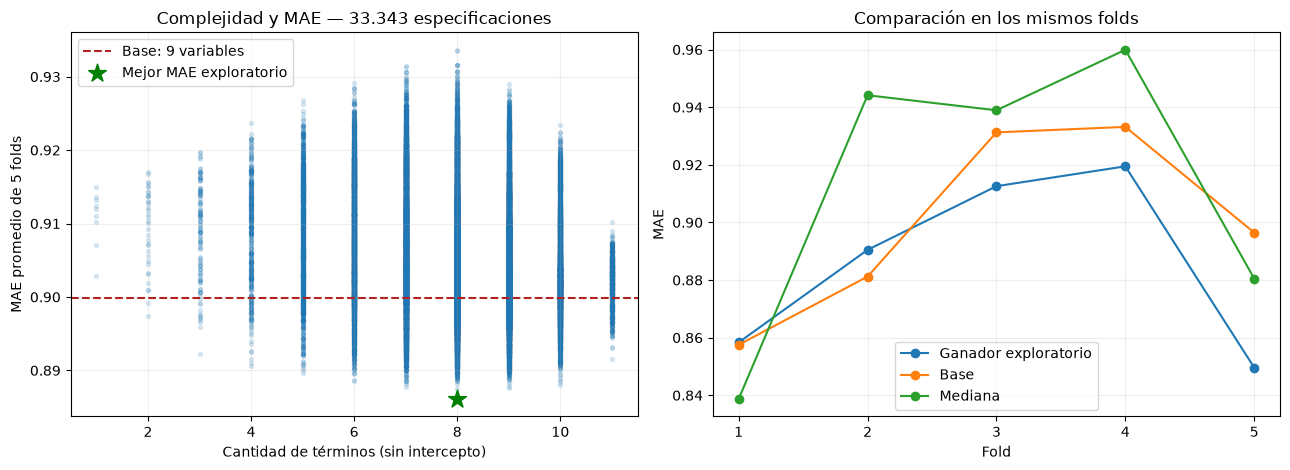

In [6]:
GANADOR_ID = int(ranking.iloc[0].modelo_id)
comparacion_folds = pd.DataFrame({
    "fold": np.arange(1, N_FOLDS + 1),
    "mae_ganador": maes[GANADOR_ID],
    "mae_base": maes[BASE_ID],
    "mae_mediana": [metricas(f, np.full(len(f["yv"]), f["mediana"]))[0] for f in preparados],
    "r2_ganador": r2s[GANADOR_ID],
    "r2_base": r2s[BASE_ID],
})
comparacion_folds["delta_mae"] = comparacion_folds.mae_ganador - comparacion_folds.mae_base
comparacion_folds.to_csv(SALIDA / "comparacion_ganador_por_fold.csv", index=False)
display(comparacion_folds.round(5))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].scatter(ranking.n_terminos, ranking.mae_promedio, s=8, alpha=0.15)
axes[0].axhline(maes[BASE_ID].mean(), color="firebrick", linestyle="--", label="Base: 9 variables")
axes[0].scatter(len(columnas_modelos[GANADOR_ID]), maes[GANADOR_ID].mean(),
                color="green", marker="*", s=180, label="Mejor MAE exploratorio", zorder=5)
axes[0].set(xlabel="Cantidad de términos (sin intercepto)", ylabel="MAE promedio de 5 folds",
            title="Complejidad y MAE — 33.343 especificaciones")
axes[0].legend()
for nombre, valores in [("Ganador exploratorio", maes[GANADOR_ID]), ("Base", maes[BASE_ID]),
                       ("Mediana", comparacion_folds.mae_mediana)]:
    axes[1].plot(range(1, 6), valores, marker="o", label=nombre)
axes[1].set(xlabel="Fold", ylabel="MAE", title="Comparación en los mismos folds", xticks=range(1, 6))
axes[1].legend()
for ax in axes:
    ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## 6. Validación anidada: búsqueda completa dentro de cada entrenamiento
Se ejecutan otras cinco búsquedas de 33.343 modelos. En cada una se usan 540 observaciones para la búsqueda interna (5 folds) y 135 para la evaluación externa.

Los resultados externos **no participan** en elegir las variables, las interacciones o el ganador de otro fold. El catálogo de candidatos y la regla de selección permanecen fijos. La base de 9 variables y la mediana se evalúan sobre las mismas reservas externas.

Puede desactivarse esta sección con `EJECUTAR_ANIDADA = False` para una exploración rápida; en ese caso el ranking principal no proporciona una evaluación externa de la selección.


In [7]:
resultados_externos = []
particiones_internas = []
if EJECUTAR_ANIDADA:
    for externo, (train_ext, valid_ext) in enumerate(particiones, 1):
        internas = list(KFold(N_FOLDS, shuffle=True, random_state=SEED).split(train_ext))
        folds_int = preparar_folds(Z[train_ext], y[train_ext], internas)
        for fi, (ti, vi) in enumerate(internas, 1):
            assert set(train_ext[ti]).isdisjoint(valid_ext)
            assert set(train_ext[vi]).isdisjoint(valid_ext)
            particiones_internas.extend(
                {"fold_externo": externo, "fila_original": int(fila), "fold_interno": fi}
                for fila in train_ext[vi]
            )
        mae_int, r2_int = buscar(folds_int, f"Anidada externo {externo}/5")
        rank_int = ordenar(mae_int, r2_int)
        elegido = int(rank_int.iloc[0].modelo_id)

        externo_preparado = preparar_folds(Z, y, [(train_ext, valid_ext)])[0]
        with threadpool_limits(limits=1):
            pred = predecir(externo_preparado, columnas_modelos[elegido])
            pred_base = predecir(externo_preparado, columnas_modelos[BASE_ID])
        mae_ext, r2_ext = metricas(externo_preparado, pred)
        mae_base, r2_base = metricas(externo_preparado, pred_base)
        mae_med, r2_med = metricas(externo_preparado,
            np.full(len(valid_ext), externo_preparado["mediana"]))
        resultados_externos.append({
            "fold_externo": externo, "modelo_id": elegido,
            "variables": catalogo.iloc[elegido]["variables"],
            "interacciones": catalogo.iloc[elegido]["interacciones"],
            "n_terminos": int(catalogo.iloc[elegido].n_terminos),
            "n_busqueda": len(train_ext), "n_evaluacion_externa": len(valid_ext),
            "mae_interno_ganador": float(rank_int.iloc[0].mae_promedio),
            "mae_externo": mae_ext, "r2_externo": r2_ext,
            "mae_base": mae_base, "r2_base": r2_base,
            "mae_mediana": mae_med, "r2_mediana": r2_med,
            "delta_mae_vs_base": mae_ext - mae_base,
        })
        # Guarda cada fold terminado para conservar resultados si se interrumpe.
        pd.DataFrame(resultados_externos).to_csv(SALIDA / "validacion_anidada_por_fold.csv", index=False)
        print(f"Fold externo {externo}: modelo {elegido}; MAE externo {mae_ext:.5f}; "
              f"MAE base {mae_base:.5f}", flush=True)

    externa = pd.DataFrame(resultados_externos)
    resumen_externo = pd.DataFrame([
        {"procedimiento": etiqueta,
         "mae_promedio": externa[mae_col].mean(), "mae_desvio": externa[mae_col].std(),
         "r2_promedio": externa[r2_col].mean(), "r2_desvio": externa[r2_col].std()}
        for etiqueta, mae_col, r2_col in [
            ("Búsqueda exhaustiva (evaluación anidada)", "mae_externo", "r2_externo"),
            ("Base fija de 9 variables", "mae_base", "r2_base"),
            ("Mediana del entrenamiento", "mae_mediana", "r2_mediana"),
        ]
    ])
    resumen_externo.to_csv(SALIDA / "validacion_anidada_resumen.csv", index=False)
    pd.DataFrame(particiones_internas).to_csv(SALIDA / "particiones_internas.csv", index=False)
    assert len(externa) == 5 and len(particiones_internas) == 5 * (len(y) * 4 // 5)
    display(externa.round(5))
    display(resumen_externo.round(5))
else:
    print("Validación anidada desactivada. El ranking sólo tiene uso exploratorio.")


Anidada externo 1/5: 2,000/33,343 modelos; 1.8 segundos


Anidada externo 1/5: 4,000/33,343 modelos; 3.1 segundos


Anidada externo 1/5: 6,000/33,343 modelos; 4.3 segundos


Anidada externo 1/5: 8,000/33,343 modelos; 5.7 segundos


Anidada externo 1/5: 10,000/33,343 modelos; 7.0 segundos


...

Anidada externo 5/5: 32,000/33,343 modelos; 32.7 segundos


Anidada externo 5/5: 33,343/33,343 modelos; 34.2 segundos


Fold externo 5: modelo 17420; MAE externo 0.90907; MAE base 0.89646


,fold_externo,modelo_id,variables,interacciones,n_terminos,n_busqueda,n_evaluacion_externa,mae_interno_ganador,mae_externo,r2_externo,mae_base,r2_base,mae_mediana,r2_mediana,delta_mae_vs_base
0,1,16560,fage + gained + sex_bin + habit_bin + marital_bin + whitemom_bin,habit_bin × marital_bin,7,540,135,0.89844,0.86051,-0.05519,0.85753,-0.03174,0.83870,-0.00427,0.00298
1,2,15124,fage + visits + gained + sex_bin + marital_bin + whitemom_bin,fage × visits + marital_bin × whitemom_bin,8,540,135,0.88207,0.89840,0.04028,0.88120,0.07445,0.94415,-0.01694,0.01720
2,3,27194,mage + visits + gained + sex_bin + habit_bin + marital_bin + whitemom_bin,mage × visits + sex_bin × marital_bin,9,540,135,0.88197,0.91954,-0.01360,0.93126,-0.00456,0.93893,-0.00064,-0.01172
3,4,8668,mage + gained + sex_bin + marital_bin + whitemom_bin,mage × gained + marital_bin × whitemom_bin,7,540,135,0.87924,0.91805,0.11320,0.93317,0.09435,0.95993,-0.00061,-0.01511
4,5,17420,mage + visits + gained + sex_bin + habit_bin + whitemom_bin,mage × visits + gained × whitemom_bin,8,540,135,0.88954,0.90907,0.00270,0.89646,0.03054,0.88052,-0.00447,0.01261


,procedimiento,mae_promedio,mae_desvio,r2_promedio,r2_desvio
0,Búsqueda exhaustiva (evaluación anidada),0.90111,0.02422,0.01748,0.06354
1,Base fija de 9 variables,0.89992,0.03258,0.03261,0.05265
2,Mediana del entrenamiento,0.91244,0.05103,-0.00539,0.00673


## 7. Lectura de resultados y ecuación exploratoria
El modelo que encabeza el ranking principal se puede ajustar con todos los datos de entrenamiento para obtener una ecuación. Sus coeficientes no son otra evaluación del error.

Si la búsqueda no mejora a la base en la evaluación externa, no hay evidencia en esta prueba de que buscar más combinaciones haya mejorado la predicción. Si varios modelos obtienen resultados similares, la cantidad de términos y la estabilidad entre folds ayudan a elegir una explicación más simple. Los resultados externos evalúan esta búsqueda predefinida; reutilizarlos para ajustar repetidamente la búsqueda volvería a introducir sesgo de selección.


In [8]:
cols_ganador = columnas_modelos[GANADOR_ID]
ajuste_final = LinearRegression().fit(Z[:, cols_ganador], y)
coeficientes = pd.DataFrame({
    "termino": ["intercepto"] + [nombres_terminos[c] for c in cols_ganador],
    "coeficiente": [ajuste_final.intercept_] + ajuste_final.coef_.tolist(),
})
coeficientes.to_csv(SALIDA / "coeficientes_ganador_exploratorio.csv", index=False)
print("GANADOR DEL RANKING EXPLORATORIO")
display(ranking.head(1).round(5))
display(coeficientes.round(6))
if EJECUTAR_ANIDADA:
    dif = externa.mae_externo.mean() - externa.mae_base.mean()
    print(f"MAE anidado de la búsqueda: {externa.mae_externo.mean():.5f}")
    print(f"MAE externo de la base:    {externa.mae_base.mean():.5f}")
    print(f"Diferencia búsqueda - base: {dif:+.5f} lb")
    print(f"Folds externos donde mejora el MAE: {int((externa.delta_mae_vs_base < -TOL).sum())}/5")
    print("La búsqueda mejora el promedio externo en esta evaluación." if dif < -TOL
          else "La búsqueda no mejora el promedio externo de la base en esta evaluación.")
print(f"Archivos guardados en: {SALIDA.resolve()}")


GANADOR DEL RANKING EXPLORATORIO


,ranking_mae,modelo_id,variables,interacciones,n_variables,n_interacciones,n_terminos,mae_promedio,mae_desvio,r2_promedio,r2_desvio,delta_mae_vs_base,delta_r2_vs_base,folds_mejora_mae_vs_base
0,1,16661,fage + gained + sex_bin + habit_bin + marital_bin + whitemom_bin,sex_bin × marital_bin + marital_bin × whitemom_bin,6,2,8,0.8861,0.03137,0.04613,0.06168,-0.01382,0.01353,3


,termino,coeficiente
0,intercepto,6.513192
1,fage,0.012296
2,gained,0.007241
3,sex_bin,0.181030
4,habit_bin,-0.611338
5,marital_bin,-0.523594
6,whitemom_bin,0.159964
7,sex_bin × marital_bin,0.284164
8,marital_bin × whitemom_bin,0.428741


MAE anidado de la búsqueda: 0.90111
MAE externo de la base:    0.89992
Diferencia búsqueda - base: +0.00119 lb
Folds externos donde mejora el MAE: 2/5
La búsqueda no mejora el promedio externo de la base en esta evaluación.
Archivos guardados en: G:\My Drive\W\2026-2C-Labo-de-datos\LdD2026 modificacion\TPs\TP1\Resultados fuerza bruta
